In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
from pathlib import Path
from scipy.ndimage import uniform_filter1d

In [2]:
BASE = Path('../runs/poster')
runs = {
    'M = 16':  BASE / 'm16'  / 'train_log.csv',
    'M = 64':  BASE / 'm64'  / 'train_log.csv',
    'M = 256': BASE / 'm256' / 'train_log.csv',
}
dfs = {label: pd.read_csv(path) for label, path in runs.items()}

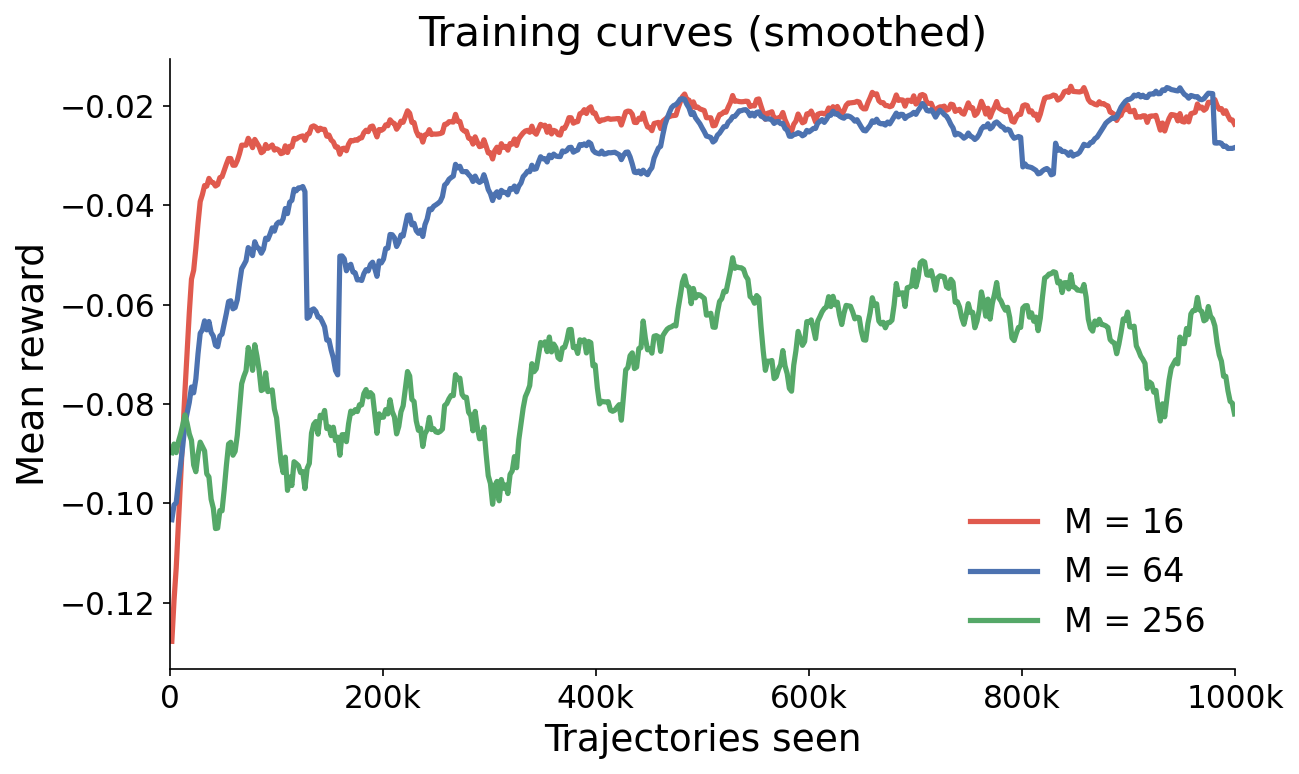

Saved to ../outputs/poster_figures/


In [3]:
# ── Poster style ────────────────────────────────────────────────────────────
plt.rcParams.update({
    'font.family':       'sans-serif',
    'font.size':         18,
    'axes.titlesize':    20,
    'axes.labelsize':    18,
    'xtick.labelsize':   15,
    'ytick.labelsize':   15,
    'legend.fontsize':   16,
    'lines.linewidth':   2.5,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'figure.dpi':        150,
})

COLORS     = ['#E05A4E', '#4C72B0', '#55A868']   # red, blue, green
SMOOTH     = 15           # uniform-filter window (steps)
TOTAL_TRAJ = 1_000_000   # x-axis upper limit (trajectories seen)

OUT = Path('../outputs/poster_figures')
OUT.mkdir(parents=True, exist_ok=True)


def smooth(x, w=SMOOTH):
    return uniform_filter1d(x, size=w, mode='nearest')


fig, ax = plt.subplots(figsize=(9, 5.5))

for (label, df), color in zip(dfs.items(), COLORS):
    # traj column = step * batch_size, already in the log
    df = df[df['traj'] <= TOTAL_TRAJ]
    traj   = df['traj'].values
    r_mean = df['reward_mean'].values
    r_std  = df['reward_std'].values

    s_mean = smooth(r_mean)
    s_std  = smooth(r_std)

    ax.plot(traj, s_mean, color=color, label=label)
    # ax.fill_between(traj, s_mean - s_std, s_mean + s_std,
    #                 color=color, alpha=0.18, linewidth=0)

ax.set_xlabel('Trajectories seen')
ax.set_ylabel('Mean reward')
ax.set_title('Training curves (smoothed)')
ax.set_xlim(0, TOTAL_TRAJ)
ax.legend(frameon=False)
ax.xaxis.set_major_formatter(ticker.FuncFormatter(
    lambda x, _: f'{int(x/1000)}k' if x > 0 else '0'
))

fig.tight_layout()
fig.savefig(OUT / 'poster_training_curves.pdf', bbox_inches='tight')
fig.savefig(OUT / 'poster_training_curves.png', bbox_inches='tight', dpi=300)
plt.show()
print(f'Saved to {OUT}/')

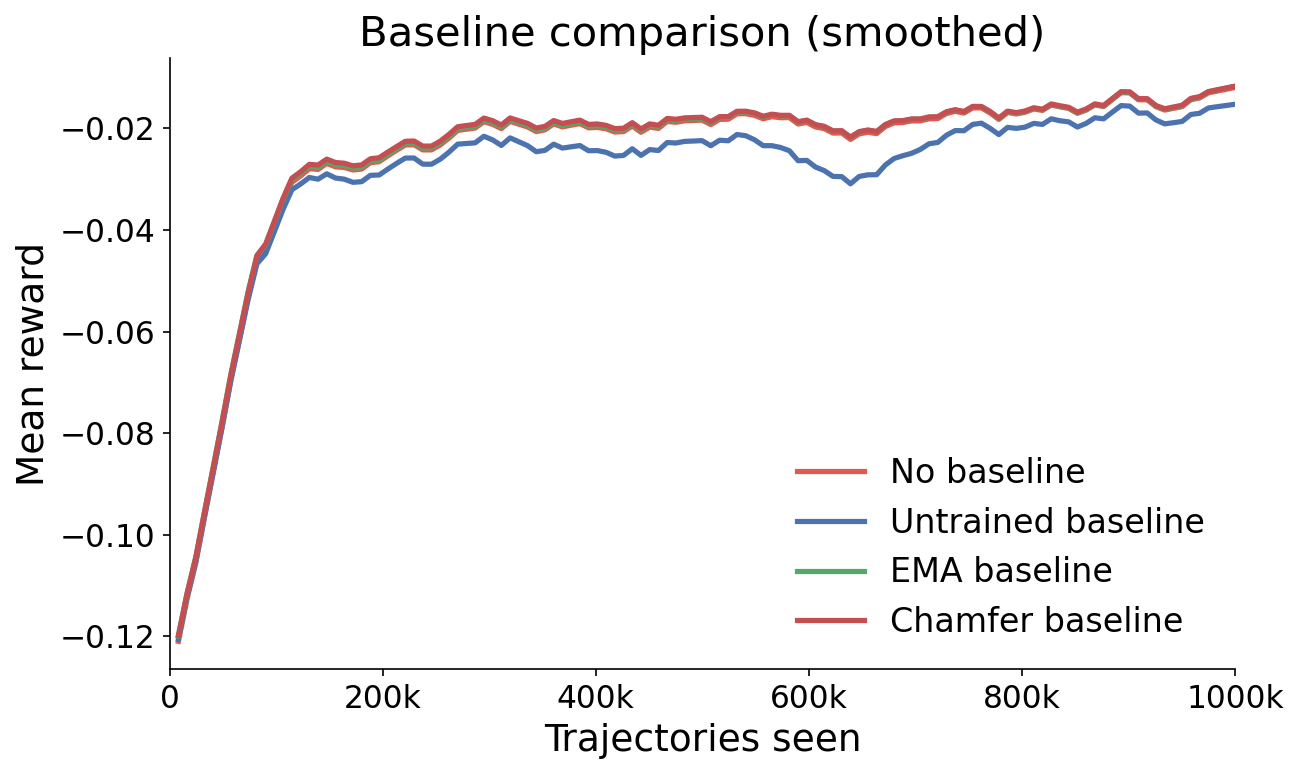

Saved to ../outputs/poster_figures/


In [8]:
baseline_runs = {
    'No baseline':        BASE / 'baseline_none'       / 'train_log.csv',
    'Untrained baseline': BASE / 'baseline_randominit' / 'train_log.csv',
    'EMA baseline':       BASE / 'baseline_ema'        / 'train_log.csv',
    'Chamfer baseline':   BASE / 'baseline_chamfer'    / 'train_log.csv',
}
TOTAL_TRAJ = 1_000_000
baseline_dfs = {label: pd.read_csv(path) for label, path in baseline_runs.items()}

BASELINE_COLORS = ['#E05A4E', '#4C72B0', '#55A868', '#C44E52']

fig, ax = plt.subplots(figsize=(9, 5.5))

for (label, df), color in zip(baseline_dfs.items(), BASELINE_COLORS):
    df = df[df['traj'] <= TOTAL_TRAJ]
    traj   = df['traj'].values
    r_mean = df['reward_mean'].values
    r_std  = df['reward_std'].values

    # print(r_mean)
    s_mean = smooth(r_mean)
    s_std  = smooth(r_std)

    ax.plot(traj, s_mean, color=color, label=label)

ax.set_xlabel('Trajectories seen')
ax.set_ylabel('Mean reward')
ax.set_title('Baseline comparison (smoothed)')
ax.set_xlim(0, TOTAL_TRAJ)
ax.legend(frameon=False)
ax.xaxis.set_major_formatter(ticker.FuncFormatter(
    lambda x, _: f'{int(x/1000)}k' if x > 0 else '0'
))

fig.tight_layout()
fig.savefig(OUT / 'poster_baseline_curves.pdf', bbox_inches='tight')
fig.savefig(OUT / 'poster_baseline_curves.png', bbox_inches='tight', dpi=300)
plt.show()
print(f'Saved to {OUT}/')

[-0.0953428 -0.107607  -0.0573075 -0.11081   -0.109893  -0.108467
 -0.0524821 -0.0955944 -0.0587764 -0.132223  -0.0492517 -0.0529215
 -0.05027   -0.0458752 -0.085114  -0.0827809 -0.0828105 -0.081886
 -0.0792338 -0.0394896 -0.0393373 -0.0399984 -0.0744949 -0.0915087
 -0.0854806 -0.0868523 -0.0707015 -0.080605  -0.0384891 -0.0377115
 -0.0825115 -0.0368721 -0.0376453 -0.0388894 -0.0352112 -0.0795438
 -0.0358917 -0.0360956 -0.0347639 -0.0314924 -0.0786254 -0.0634109
 -0.0350641 -0.0604586 -0.0696655 -0.0284828 -0.0559731 -0.0569406
 -0.067182  -0.0271717 -0.031294  -0.0524731 -0.0262263 -0.0257002
 -0.0501978 -0.0593901 -0.0587313 -0.0472399 -0.0475506 -0.0278388
 -0.052963  -0.0220166 -0.0497844 -0.02221   -0.0290135 -0.0212866
 -0.0416488 -0.0212335 -0.0413544 -0.0189877 -0.0483656 -0.0250147
 -0.0404902 -0.0470491 -0.0384705 -0.0371731 -0.0255218 -0.0436715
 -0.0435177 -0.0173454 -0.0332483 -0.03931   -0.0323846 -0.0317175
 -0.0373398 -0.0218629 -0.0192732 -0.034278  -0.0168834 -0.02230

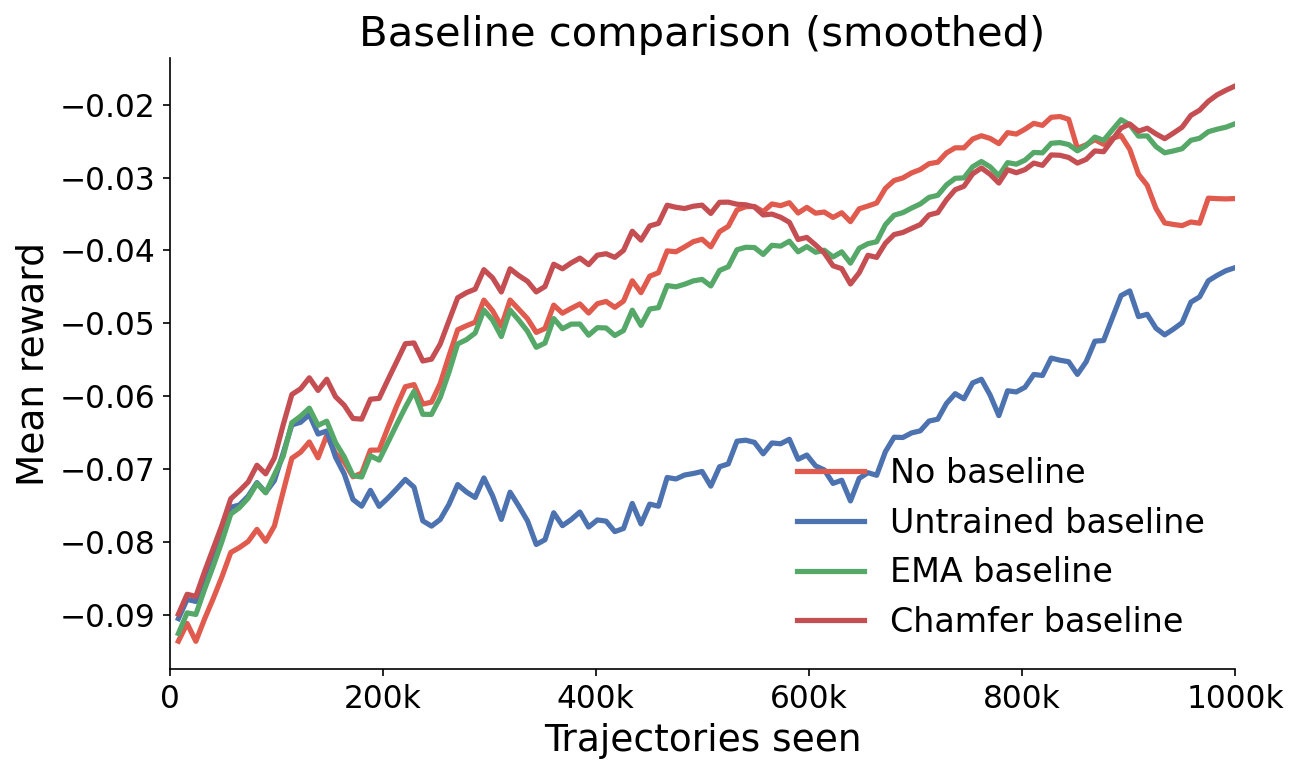

Saved to ../outputs/poster_figures/


In [5]:
baseline_runs = {
    'No baseline':        BASE / 'baseline_none_128'       / 'train_log.csv',
    'Untrained baseline': BASE / 'baseline_prior_128' / 'train_log.csv',
    'EMA baseline':       BASE / 'baseline_ema_128'        / 'train_log.csv',
    'Chamfer baseline':   BASE / 'baseline_chamfer_128'    / 'train_log.csv',
}
baseline_dfs = {label: pd.read_csv(path) for label, path in baseline_runs.items()}

BASELINE_COLORS = ['#E05A4E', '#4C72B0', '#55A868', '#C44E52']

fig, ax = plt.subplots(figsize=(9, 5.5))

for (label, df), color in zip(baseline_dfs.items(), BASELINE_COLORS):
    df = df[df['traj'] <= TOTAL_TRAJ]
    traj   = df['traj'].values
    r_mean = df['reward_mean'].values
    r_std  = df['reward_std'].values

    print(r_mean)
    s_mean = smooth(r_mean)
    s_std  = smooth(r_std)

    ax.plot(traj, s_mean, color=color, label=label)

ax.set_xlabel('Trajectories seen')
ax.set_ylabel('Mean reward')
ax.set_title('Baseline comparison (smoothed)')
ax.set_xlim(0, TOTAL_TRAJ)
ax.legend(frameon=False)
ax.xaxis.set_major_formatter(ticker.FuncFormatter(
    lambda x, _: f'{int(x/1000)}k' if x > 0 else '0'
))

fig.tight_layout()
fig.savefig(OUT / 'poster_baseline_curves.pdf', bbox_inches='tight')
fig.savefig(OUT / 'poster_baseline_curves.png', bbox_inches='tight', dpi=300)
plt.show()
print(f'Saved to {OUT}/')

(610, 11)
(610, 11)
(610, 11)
(610, 11)


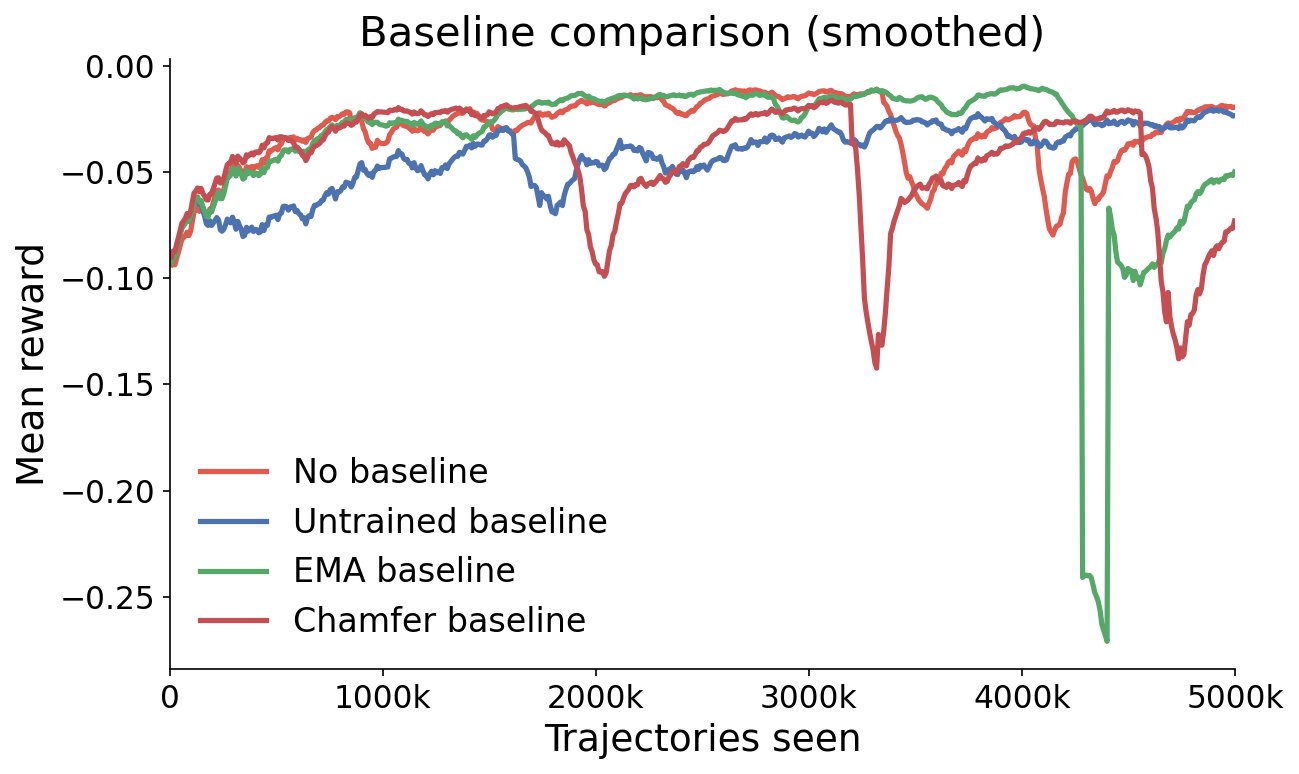

Saved to ../outputs/poster_figures/


In [9]:
TOTAL_TRAJ = 5_000_000
baseline_runs = {
    'No baseline':        BASE / 'baseline_none_128'       / 'train_log.csv',
    'Untrained baseline': BASE / 'baseline_prior_128' / 'train_log.csv',
    'EMA baseline':       BASE / 'baseline_ema_128'        / 'train_log.csv',
    'Chamfer baseline':   BASE / 'baseline_chamfer_128'    / 'train_log.csv',
}
baseline_dfs = {label: pd.read_csv(path) for label, path in baseline_runs.items()}

BASELINE_COLORS = ['#E05A4E', '#4C72B0', '#55A868', '#C44E52']

fig, ax = plt.subplots(figsize=(9, 5.5))

for (label, df), color in zip(baseline_dfs.items(), BASELINE_COLORS):
    df = df[df['traj'] <= TOTAL_TRAJ]
    traj   = df['traj'].values
    r_mean = df['reward_mean'].values
    r_std  = df['reward_std'].values

    print(df.shape)
    s_mean = smooth(r_mean)
    s_std  = smooth(r_std)

    ax.plot(traj, s_mean, color=color, label=label)

ax.set_xlabel('Trajectories seen')
ax.set_ylabel('Mean reward')
ax.set_title('Baseline comparison (smoothed)')
ax.set_xlim(0, TOTAL_TRAJ)
ax.legend(frameon=False)
ax.xaxis.set_major_formatter(ticker.FuncFormatter(
    lambda x, _: f'{int(x/1000)}k' if x > 0 else '0'
))

fig.tight_layout()
fig.savefig(OUT / 'poster_baseline_curves.pdf', bbox_inches='tight')
fig.savefig(OUT / 'poster_baseline_curves.png', bbox_inches='tight', dpi=300)
plt.show()
print(f'Saved to {OUT}/')

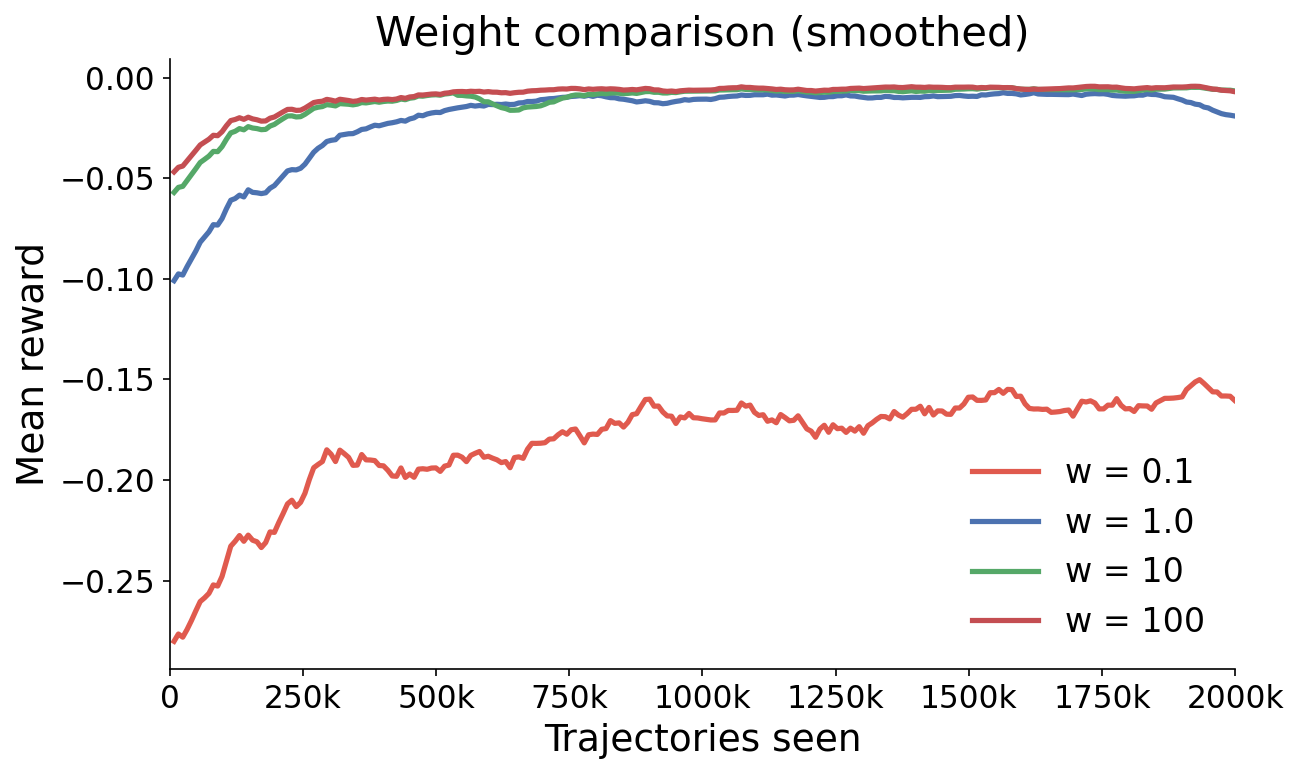

Saved to ../outputs/poster_figures/


In [8]:
TOTAL_TRAJ = 2_000_000

BASE = Path('../runs/report/data-weight')

baseline_runs = {
    'w = 0.1':        BASE / '0.1'       / 'train_log.csv',
    'w = 1.0': BASE / '1.0' / 'train_log.csv',
    'w = 10':       BASE / '10.0'        / 'train_log.csv',
    'w = 100':   BASE / '100.0'    / 'train_log.csv',
}
baseline_dfs = {label: pd.read_csv(path) for label, path in baseline_runs.items()}

BASELINE_COLORS = ['#E05A4E', '#4C72B0', '#55A868', '#C44E52']

fig, ax = plt.subplots(figsize=(9, 5.5))

for (label, df), color in zip(baseline_dfs.items(), BASELINE_COLORS):
    df = df[df['traj'] <= TOTAL_TRAJ]
    traj   = df['traj'].values
    r_mean = df['reward_mean'].values
    r_std  = df['reward_std'].values

    # print(r_mean)
    s_mean = smooth(r_mean)
    s_std  = smooth(r_std)

    ax.plot(traj, s_mean, color=color, label=label)

ax.set_xlabel('Trajectories seen')
ax.set_ylabel('Mean reward')
ax.set_title('Weight comparison (smoothed)')
ax.set_xlim(0, TOTAL_TRAJ)
ax.legend(frameon=False)
ax.xaxis.set_major_formatter(ticker.FuncFormatter(
    lambda x, _: f'{int(x/1000)}k' if x > 0 else '0'
))

fig.tight_layout()
fig.savefig(OUT / 'poster_baseline_curves.pdf', bbox_inches='tight')
fig.savefig(OUT / 'poster_baseline_curves.png', bbox_inches='tight', dpi=300)
plt.show()
print(f'Saved to {OUT}/')

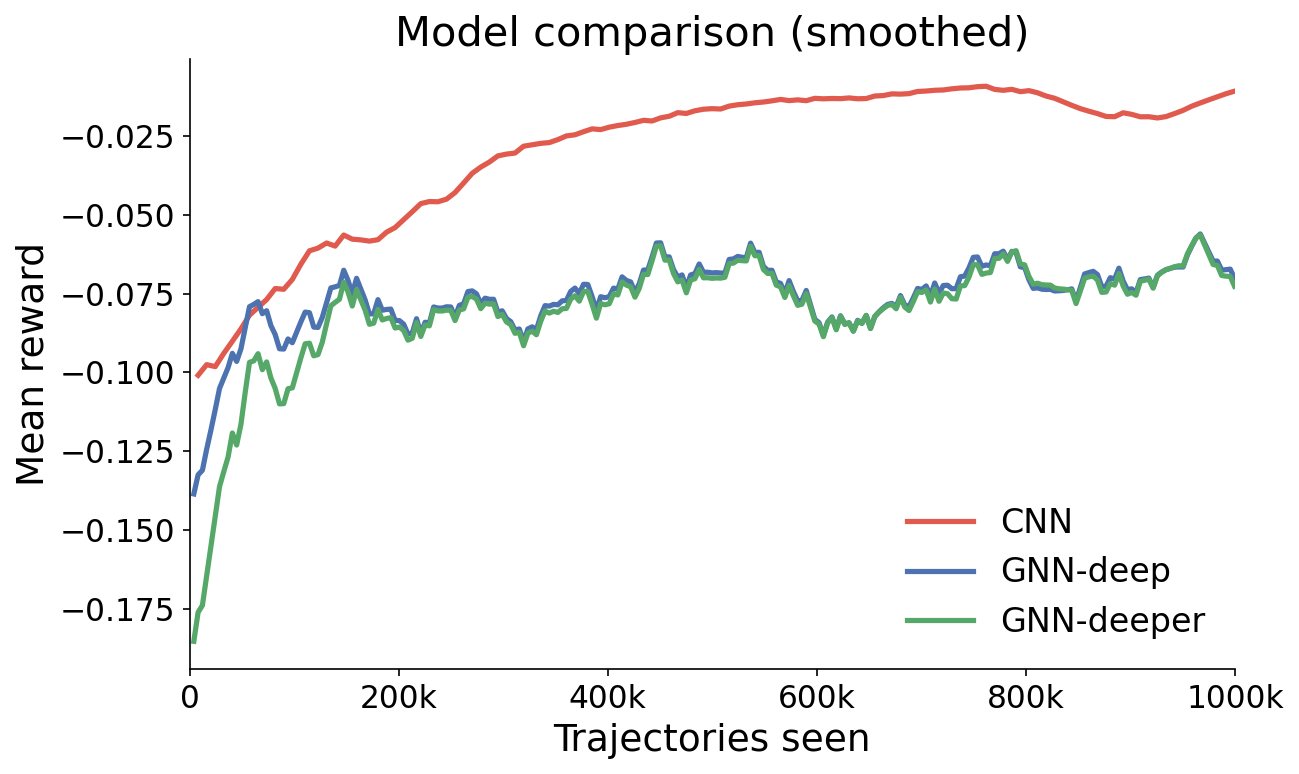

Saved to ../outputs/poster_figures/


In [9]:
TOTAL_TRAJ = 1_000_000

BASE = Path('../outputs/train_matcher/cnn_vs_gnn')
baseline_runs = {
    'CNN':        BASE / 'cnn' / 'train_log.csv',
    'GNN-deep': BASE / 'gnn_deep' / 'train_log.csv',
    'GNN-deeper': BASE / 'gnn_deeper' / 'train_log.csv',
}

baseline_dfs = {label: pd.read_csv(path) for label, path in baseline_runs.items()}

BASELINE_COLORS = ['#E05A4E', '#4C72B0', '#55A868', '#C44E52']

fig, ax = plt.subplots(figsize=(9, 5.5))

for (label, df), color in zip(baseline_dfs.items(), BASELINE_COLORS):
    df = df[df['traj'] <= TOTAL_TRAJ]
    traj   = df['traj'].values
    r_mean = df['reward_mean'].values
    r_std  = df['reward_std'].values

    # print(r_mean)
    s_mean = smooth(r_mean)
    s_std  = smooth(r_std)

    ax.plot(traj, s_mean, color=color, label=label)

ax.set_xlabel('Trajectories seen')
ax.set_ylabel('Mean reward')
ax.set_title('Model comparison (smoothed)')
ax.set_xlim(0, TOTAL_TRAJ)
ax.legend(frameon=False)
ax.xaxis.set_major_formatter(ticker.FuncFormatter(
    lambda x, _: f'{int(x/1000)}k' if x > 0 else '0'
))

fig.tight_layout()
fig.savefig(OUT / 'poster_baseline_curves.pdf', bbox_inches='tight')
fig.savefig(OUT / 'poster_baseline_curves.png', bbox_inches='tight', dpi=300)
plt.show()
print(f'Saved to {OUT}/')